# Wine Reviews: Exploratory Data Analysis

## 基本情報

- 主題: Wine Review の EDA
- 作成者: 荒田禎之
- 位置づけ: データの読み込み、確認
- 使用データ: Wine Review
- 分析課題: Wine Review を読み込み、要約統計を見る
- 到達目標:
  - データの読み込み
  - 欠損値や outlier など、機械学習モデルを構築する前に確認すべき点を確認する

This notebook includes code and explanations generated with OpenAI Codex.

---

## 1. 今回の方針

この notebook ではファイルを読み込み、データ品質、要約統計、主要変数の分布と関係を確認する。  

このセルでは分析に必要なライブラリを読み込む。`Path` はCSVファイルの位置確認、`pandas` と `numpy` はデータ処理、`matplotlib` と `seaborn` は可視化に使用する。続いて、表の全列を省略せず表示する設定、浮動小数点数を小数第2位まで表示する設定、グラフの共通テーマを指定する。

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")

## 1. データの読み込み

現在の working directory から見て `data/winemag-data-130k-v2.csv` にデータがある前提で実行している。  

<!-- （プロジェクトルートから実行する場合は `data/`、`notebook/` を作業ディレクトリとして実行する場合は `../data/` を参照するようにしている）

### 実行コードの説明 -->

CSVがプロジェクトルートの `data/` とnotebookディレクトリ基準の `../data/` のどちらにあるかを順に確認する。見つからない場合は探索した絶対パスを含むエラーを発生させる。読み込み後、元CSVの保存時に作られた `Unnamed:` 列を除外し、行列数と先頭5行を表示して読み込み結果を確認する。


In [4]:
filename = "winemag-data-130k-v2.csv"
candidate_paths = [Path("data") / filename, Path("../data") / filename]
csv_path = next((path for path in candidate_paths if path.exists()), None)

if csv_path is None:
    searched = "\n".join(f"- {path.resolve()}" for path in candidate_paths)
    raise FileNotFoundError(f"CSV が見つかりません。以下を確認してください。\n{searched}")

df = pd.read_csv(csv_path)

# Kaggle 版 CSV に含まれる保存時の行番号列を除外
unnamed_columns = [column for column in df.columns if column.startswith("Unnamed:")]
df = df.drop(columns=unnamed_columns)

print(f"Loaded: {csv_path.resolve()}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
display(df.head())

Loaded: /content/data/winemag-data-130k-v2.csv
Shape: 129,971 rows x 13 columns


,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.00,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.00,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.00,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.00,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


## 2. データ構造と品質の確認

`df.info()` を使い、行数、列名、各列の非欠損件数、データ型、概算メモリ使用量を一覧表示する。数値として扱う列と文字列として扱う列が想定どおりか、欠損がどの列にあるかを最初に把握するための処理である。


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129971 entries, 0 to 129970
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   country                129908 non-null  object 
 1   description            129971 non-null  object 
 2   designation            92506 non-null   object 
 3   points                 129971 non-null  int64  
 4   price                  120975 non-null  float64
 5   province               129908 non-null  object 
 6   region_1               108724 non-null  object 
 7   region_2               50511 non-null   object 
 8   taster_name            103727 non-null  object 
 9   taster_twitter_handle  98758 non-null   object 
 10  title                  129971 non-null  object 
 11  variety                129970 non-null  object 
 12  winery                 129971 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 12.9+ MB


### 欠損・重複・ユニーク数を確認するコード

各列について欠損件数、欠損率、欠損を除いたユニーク値数を計算し、欠損率が高い順に並べる。また、全列の値が一致する重複行数も表示する。欠損補完や列の除外、カテゴリ変数の扱いを検討するための基礎情報となる。


In [6]:
missing_summary = (
    pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_rate_pct": df.isna().mean().mul(100),
        "n_unique": df.nunique(dropna=True),
    })
    .sort_values("missing_rate_pct", ascending=False)
)

print(f"Duplicated rows: {df.duplicated().sum():,}")
display(missing_summary)

Duplicated rows: 9,983


,missing_count,missing_rate_pct,n_unique
region_2,79460,61.14,17
designation,37465,28.83,37979
taster_twitter_handle,31213,24.02,15
taster_name,26244,20.19,19
region_1,21247,16.35,1229
price,8996,6.92,390
province,63,0.05,425
country,63,0.05,43
variety,1,0.00,707
points,0,0.00,21


### 要約統計を確認するコード

最初の `describe()` は数値列の件数、平均、標準偏差、最小値、四分位点、最大値を表示する。次の `describe(include=["object"])` は文字列列の件数、ユニーク値数、最頻値、その出現数を表示する。転置して、1行を1変数として読みやすくしている。


In [7]:
# 数値列とカテゴリ列の要約統計
display(df.describe().T)
display(df.describe(include=["object"]).T)

,count,mean,std,min,25%,50%,75%,max
points,"129,971.00",88.45,3.04,80.00,86.00,88.00,91.00,100.00
price,"120,975.00",35.36,41.02,4.00,17.00,25.00,42.00,"3,300.00"


,count,unique,top,freq
country,129908,43,US,54504
description,129971,119955,"Seductively tart in lemon pith, cranberry and ...",3
designation,92506,37979,Reserve,2009
province,129908,425,California,36247
region_1,108724,1229,Napa Valley,4480
region_2,50511,17,Central Coast,11065
taster_name,103727,19,Roger Voss,25514
taster_twitter_handle,98758,15,@vossroger,25514
title,129971,118840,Gloria Ferrer NV Sonoma Brut Sparkling (Sonoma...,11
variety,129970,707,Pinot Noir,13272


## 3. 評価点と価格の分布

左側では評価点 `points` を離散値として数えたヒストグラムを描く。右側では価格 `price` のヒストグラムを描き、少数の高価格ワインによる長い右裾を確認しやすくするため横軸を対数スケールにする。2つの分布を並べ、値の集中や外れ値の存在を確認する。


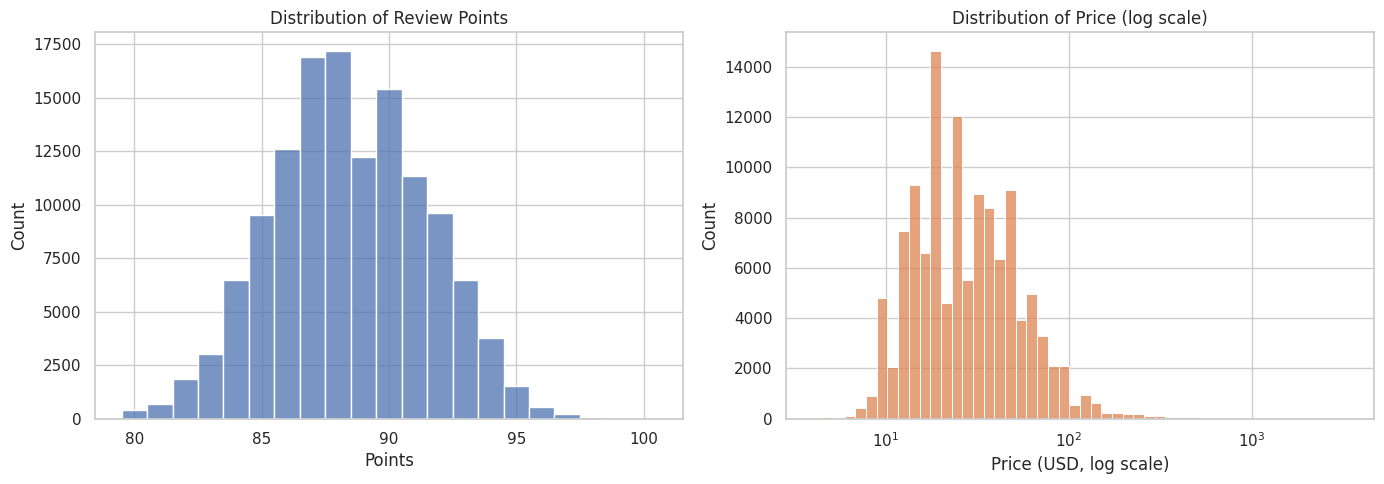

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="points", discrete=True, ax=axes[0], color="#4C72B0")
axes[0].set(title="Distribution of Review Points", xlabel="Points", ylabel="Count")

sns.histplot(data=df, x="price", bins=50, log_scale=True, ax=axes[1], color="#DD8452")
axes[1].set(title="Distribution of Price (log scale)", xlabel="Price (USD, log scale)", ylabel="Count")

plt.tight_layout()
plt.show()

価格は右裾が長い可能性があるため、横軸を対数スケールで表示しています。

## 4. 国・品種・ワイナリーの構成

`value_counts()` で国と品種ごとのレビュー件数を数え、上位15カテゴリを横棒グラフで比較する。さらに、レビュー件数が多いワイナリー上位15件を表で表示する。カテゴリの偏りや、後続モデルで出現頻度の低いカテゴリが多くなる可能性を確認する処理である。


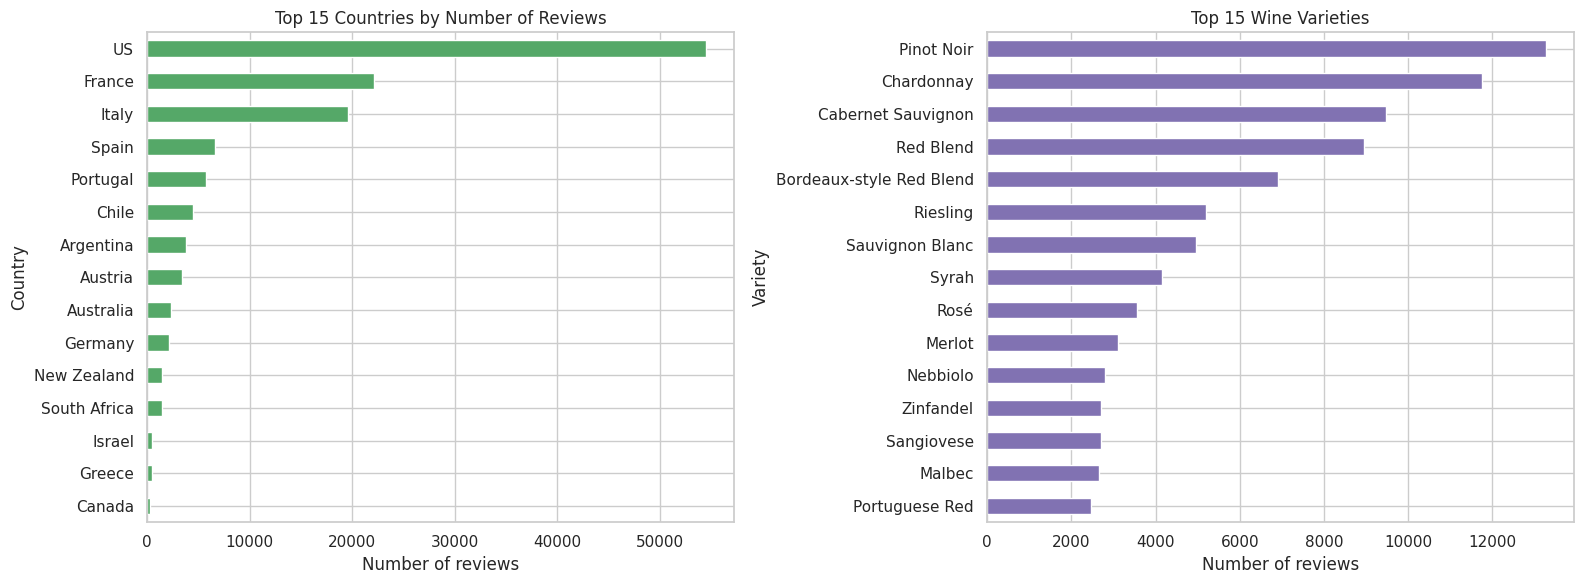

,review_count
winery,
Wines & Winemakers,222
Testarossa,218
DFJ Vinhos,215
Williams Selyem,211
Louis Latour,199
Georges Duboeuf,196
Chateau Ste. Michelle,194
Concha y Toro,164
Columbia Crest,159


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_countries = df["country"].value_counts().head(15).sort_values()
top_varieties = df["variety"].value_counts().head(15).sort_values()

top_countries.plot.barh(ax=axes[0], color="#55A868")
axes[0].set(title="Top 15 Countries by Number of Reviews", xlabel="Number of reviews", ylabel="Country")

top_varieties.plot.barh(ax=axes[1], color="#8172B2")
axes[1].set(title="Top 15 Wine Varieties", xlabel="Number of reviews", ylabel="Variety")

plt.tight_layout()
plt.show()

display(df["winery"].value_counts().head(15).rename("review_count").to_frame())

## 5. 価格と評価点の関係

価格と評価点の両方がある行だけを使い、順位に基づくSpearman相関係数を計算する。散布図は描画負荷を抑えるため最大10,000行を固定乱数で抽出し、価格軸を対数表示する。線形関係に限定せず、価格が高いほど評価点も高くなる傾向があるかを確認する。


Spearman correlation between price and points: 0.606


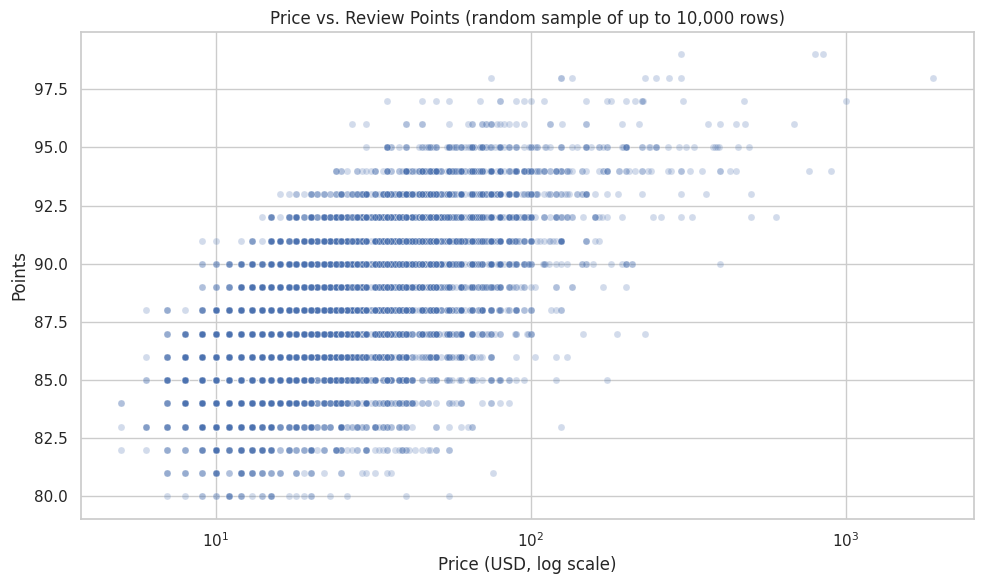

In [10]:
price_points = df[["price", "points"]].dropna()
sample = price_points.sample(n=min(10_000, len(price_points)), random_state=42)
correlation = price_points.corr(method="spearman").loc["price", "points"]

print(f"Spearman correlation between price and points: {correlation:.3f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample, x="price", y="points", alpha=0.25, s=25)
plt.xscale("log")
plt.title("Price vs. Review Points (random sample of up to 10,000 rows)")
plt.xlabel("Price (USD, log scale)")
plt.ylabel("Points")
plt.tight_layout()
plt.show()

### 評価点別の価格を集計するコード

`points` ごとに、価格が記録されたレビュー数、価格中央値、価格平均を集計する。グラフには外れ値の影響を受けにくい中央値を使用し、評価点の上昇に伴って典型的な価格がどう変化するかを確認する。表の件数は、評価点ごとの推定の安定性を判断する際にも利用できる。


,review_count,median_price,mean_price
points,,,
80,395,14.00,16.37
81,680,14.00,17.18
82,1772,15.00,18.87
83,2886,15.00,18.24
84,6099,15.00,19.31
85,8902,16.00,19.95
86,11745,18.00,22.13
87,15767,20.00,24.90
88,16014,24.00,28.69


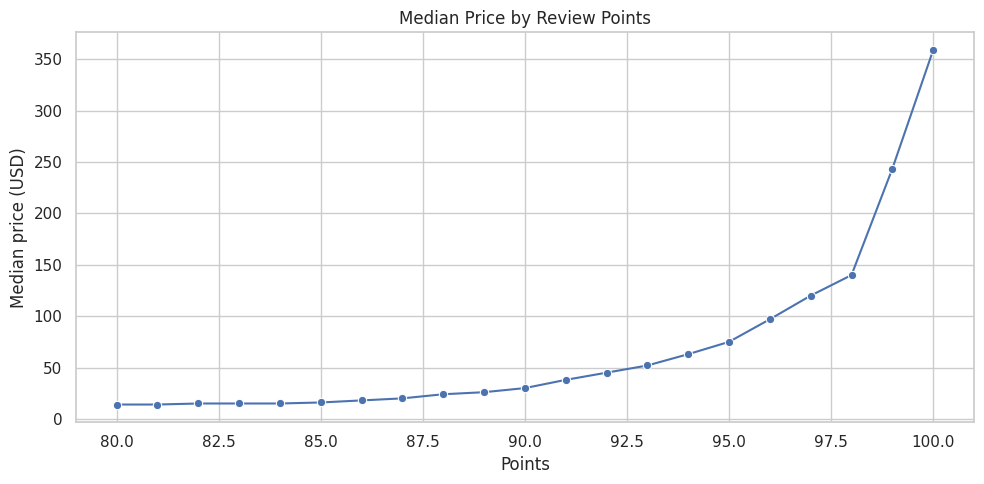

In [11]:
# 評価点ごとの価格の中央値とサンプル数
price_by_points = (
    df.groupby("points")["price"]
    .agg(review_count="count", median_price="median", mean_price="mean")
)
display(price_by_points)

plt.figure(figsize=(10, 5))
sns.lineplot(data=price_by_points, x=price_by_points.index, y="median_price", marker="o")
plt.title("Median Price by Review Points")
plt.xlabel("Points")
plt.ylabel("Median price (USD)")
plt.tight_layout()
plt.show()

## 6. レビュー本文の簡単な確認

`description` の文字数を計算し、要約統計とヒストグラムでレビュー本文の長さを確認する。これは後続のテキストモデルで最大入力長を決める際の参考になる。
<!-- 最後に、タイトル、本文、評価点、価格をランダムに5件表示し、文章内容と他の変数の対応を目視確認する。 -->


,description_length
count,"129,971.00"
mean,242.60
std,66.58
min,20.00
25%,197.00
50%,237.00
75%,282.00
max,829.00


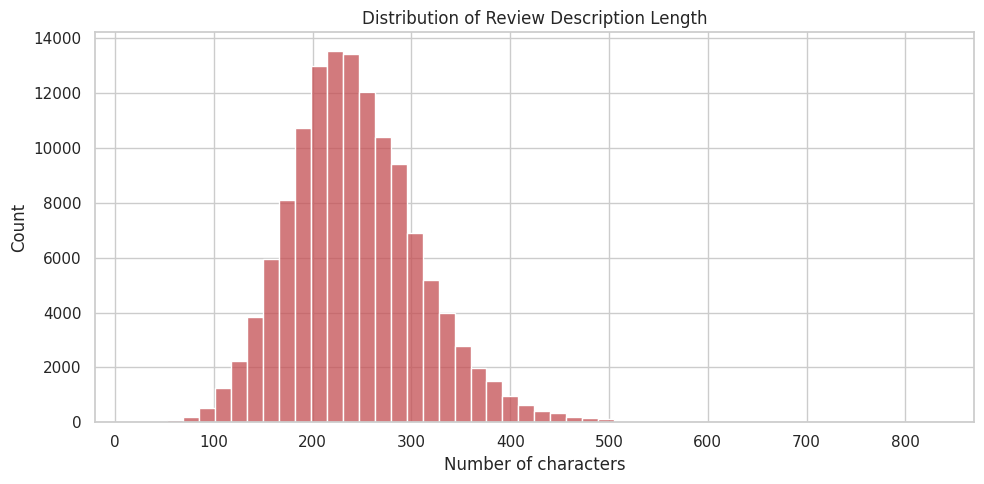

In [12]:
description_length = df["description"].str.len()
display(description_length.describe().rename("description_length").to_frame())

plt.figure(figsize=(10, 5))
sns.histplot(description_length.dropna(), bins=50, color="#C44E52")
plt.title("Distribution of Review Description Length")
plt.xlabel("Number of characters")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# display(df.loc[:, ["title", "description", "points", "price"]].sample(5, random_state=42))

## 7. EDA の確認ポイント

- 欠損率が高い列は、後続分析で除外・補完・欠損カテゴリ化のいずれを採用するか検討する。
- 価格は外れ値を含むため、モデル化では対数変換や上限処理を検討する。
- 国や品種ごとの件数には偏りがあり、単純な平均値の比較ではサンプル数も併記する。
- 同一内容の重複行がある場合は、分析目的に応じて除外する。